In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

ROOT = Path("/Users/andreali/Documents/Subgraph_Federated_Learning")
    
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
csv_path = ROOT / "andrea/heterogeneity/heterogeneity_all_pairs.csv"


df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(386760, 54)


,subset_id,subset_size,subset_clients,graph_id_i,graph_id_j,dataset_i,dataset_j,type_i,type_j,num_nodes_i,...,structure_gap,label_rates_i_json,label_rates_j_json,label_counts_i_json,label_counts_j_json,label_gap_json,taskwise_homophily_i_json,taskwise_homophily_j_json,task_homophily_gap_json,incompatibility_score
0,p_0_1,2,0|1,0,1,data_2000_7_2.0_chordal,data_4000_5_11.5_chordal,chordal,chordal,2000,...,0.123655,"[0.685, 0.747, 0.744, 0.736, 0.7085]","[0.14375, 0.219, 0.3465, 0.4725, 0.56875]","[1370.0, 1494.0, 1488.0, 1472.0, 1417.0]","[575.0, 876.0, 1386.0, 1890.0, 2275.0]","[{""task"": ""cycle2"", ""value_i"": 0.685, ""value_j...","[0.6903680501174628, 0.7911333125195129, 0.823...","[0.27573651108904335, 0.3376413570274637, 0.44...","[{""task"": ""cycle2"", ""value_i"": 0.6903680501174...",0.304761
1,p_0_2,2,0|2,0,2,data_2000_7_2.0_chordal,data_4000_3_7.5_chordal,chordal,chordal,2000,...,0.227075,"[0.685, 0.747, 0.744, 0.736, 0.7085]","[0.07625, 0.083, 0.091, 0.08375, 0.091]","[1370.0, 1494.0, 1488.0, 1472.0, 1417.0]","[305.0, 332.0, 364.0, 335.0, 364.0]","[{""task"": ""cycle2"", ""value_i"": 0.685, ""value_j...","[0.6903680501174628, 0.7911333125195129, 0.823...","[0.3157894736842105, 0.33640939597315433, 0.38...","[{""task"": ""cycle2"", ""value_i"": 0.6903680501174...",0.428199
2,p_0_3,2,0|3,0,3,data_2000_7_2.0_chordal,data_4000_1_4.5_watts,chordal,watts,2000,...,0.325343,"[0.685, 0.747, 0.744, 0.736, 0.7085]","[0.0, 0.0, 0.0, 0.0, 0.0]","[1370.0, 1494.0, 1488.0, 1472.0, 1417.0]","[0.0, 0.0, 0.0, 0.0, 0.0]","[{""task"": ""cycle2"", ""value_i"": 0.685, ""value_j...","[0.6903680501174628, 0.7911333125195129, 0.823...","[0.0, 0.0, 0.0, 0.0, 0.0]","[{""task"": ""cycle2"", ""value_i"": 0.6903680501174...",0.700783
3,p_0_4,2,0|4,0,4,data_2000_7_2.0_chordal,data_2000_2_10.5_chordal,chordal,chordal,2000,...,0.285495,"[0.685, 0.747, 0.744, 0.736, 0.7085]","[0.029, 0.0215, 0.0175, 0.0155, 0.009]","[1370.0, 1494.0, 1488.0, 1472.0, 1417.0]","[58.0, 43.0, 35.0, 31.0, 18.0]","[{""task"": ""cycle2"", ""value_i"": 0.685, ""value_j...","[0.6903680501174628, 0.7911333125195129, 0.823...","[0.36477987421383645, 0.4392523364485981, 0.42...","[{""task"": ""cycle2"", ""value_i"": 0.6903680501174...",0.534584
4,p_0_5,2,0|5,0,5,data_2000_7_2.0_chordal,data_2000_2_1.0_chordal,chordal,chordal,2000,...,0.278748,"[0.685, 0.747, 0.744, 0.736, 0.7085]","[0.2065, 0.0525, 0.012, 0.005, 0.0]","[1370.0, 1494.0, 1488.0, 1472.0, 1417.0]","[413.0, 105.0, 24.0, 10.0, 0.0]","[{""task"": ""cycle2"", ""value_i"": 0.685, ""value_j...","[0.6903680501174628, 0.7911333125195129, 0.823...","[0.6221248630887185, 0.7142857142857143, 0.686...","[{""task"": ""cycle2"", ""value_i"": 0.6903680501174...",0.398978


In [22]:
metric_cols = [
    "density_gap",
    "size_ratio",
    "size_mismatch",
    "edge_ratio",
    "in_degree_jsd",
    "out_degree_jsd",
    "motif_density_jsd",
    "motif_mean_abs_gap",
    "label_rate_jsd",
    "label_rate_mean_abs_gap",
    "labelset_size_jsd",
    "label_mixing_jsd",
    "homophily_gap",
    "task_homophily_mean_abs_gap",
    "support_count_log_gap",
    "support_regime_gap",
    "shared_support_frac",
    "low_support_task_frac",
    "complementarity_score",
    "task_profile_gap",
    "structure_gap",
]

X = df[metric_cols].copy()
X.describe().T

,count,mean,std,min,25%,50%,75%,max
density_gap,386760.0,0.000747,0.000585,0.000000e+00,0.000250,0.000625,0.001125,0.002376
size_ratio,386760.0,1.500569,0.500000,1.000000e+00,1.000000,2.000000,2.000000,2.000000
size_mismatch,386760.0,0.346968,0.346574,0.000000e+00,0.000000,0.693147,0.693147,0.693147
edge_ratio,386760.0,2.850947,2.499878,1.000000e+00,1.333333,2.000000,3.333333,20.000000
in_degree_jsd,386760.0,0.190887,0.169661,0.000000e+00,0.049254,0.133819,0.302065,0.615508
out_degree_jsd,386760.0,0.190928,0.169749,0.000000e+00,0.048918,0.134281,0.302651,0.619893
motif_density_jsd,386760.0,0.144416,0.145333,0.000000e+00,0.029547,0.096124,0.210347,0.693147
motif_mean_abs_gap,386760.0,3.059076,3.723729,0.000000e+00,0.322300,1.382800,3.454413,12.659750
label_rate_jsd,386760.0,0.078374,0.103794,-1.110145e-16,0.008187,0.045496,0.091861,0.693147
label_rate_mean_abs_gap,386760.0,0.399325,0.271038,0.000000e+00,0.167450,0.368150,0.648450,0.941700


In [23]:
pearson_corr = X.corr(method="pearson", numeric_only=True)
spearman_corr = X.corr(method="spearman", numeric_only=True)

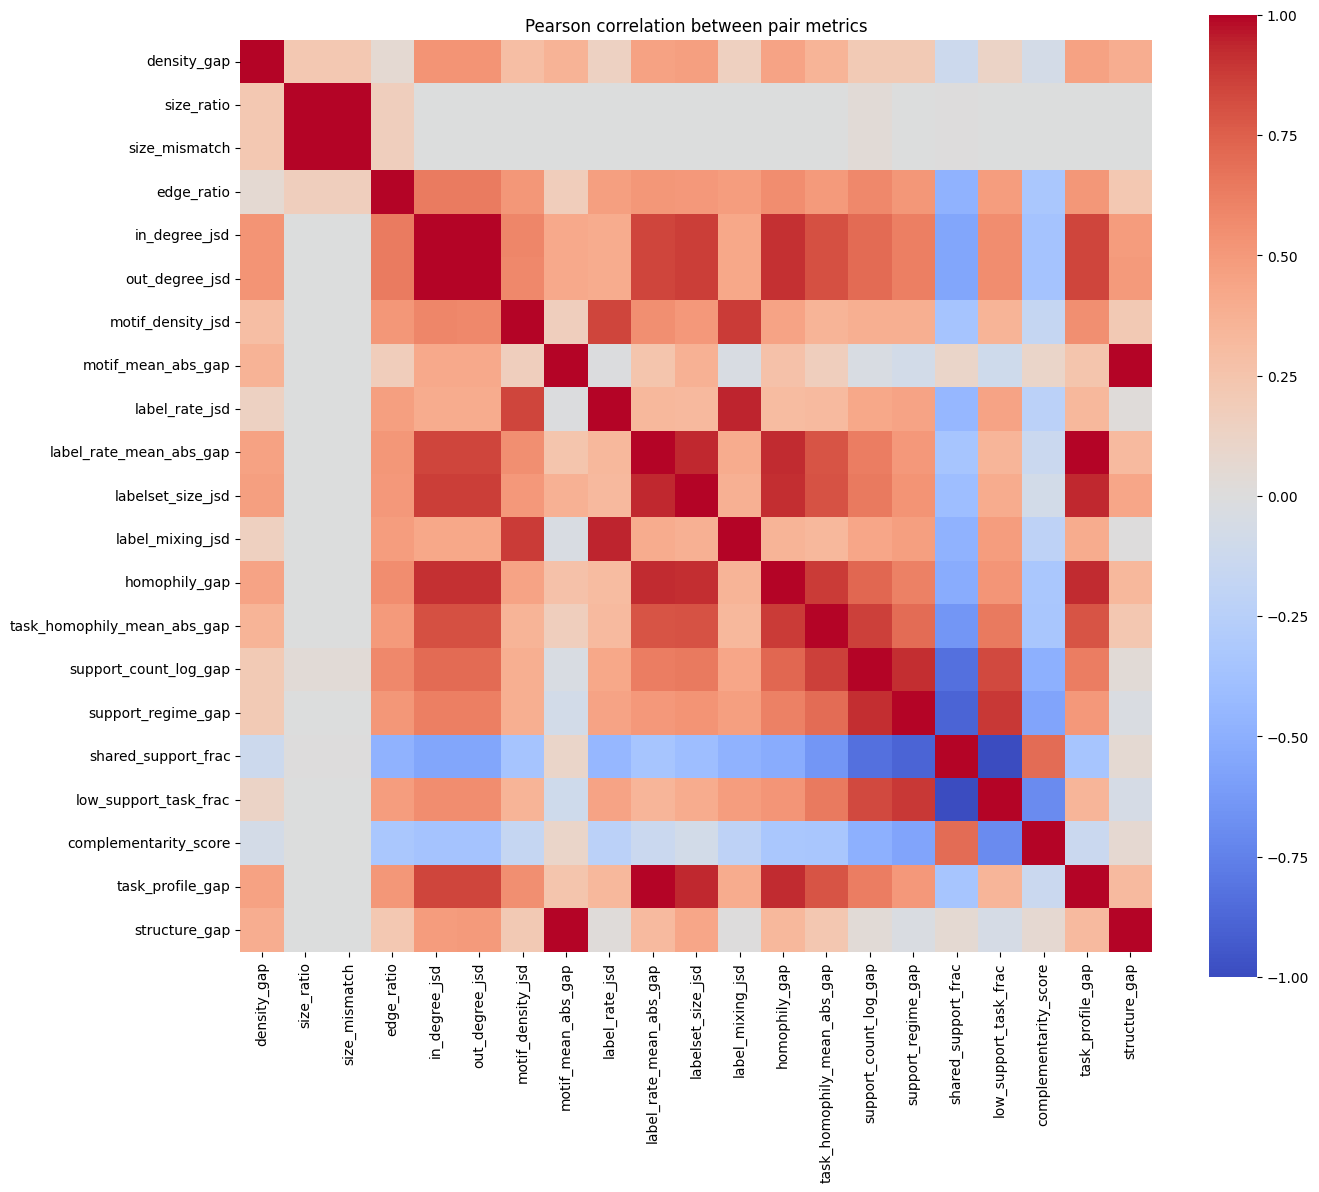

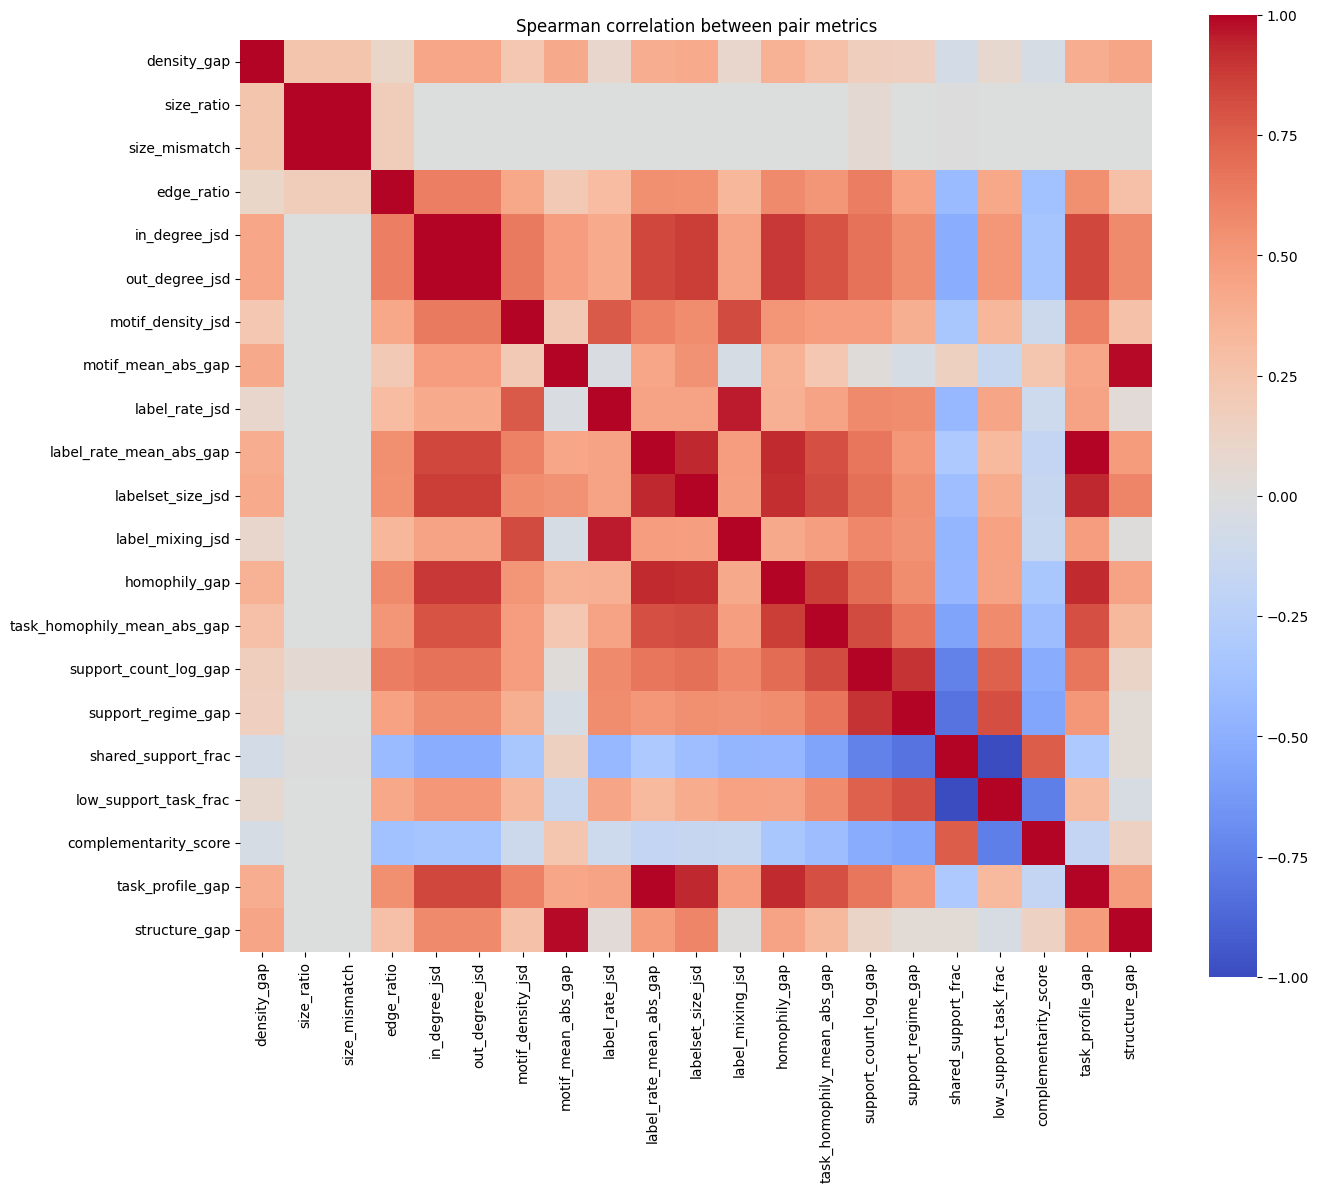

In [24]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True
)
plt.title("Pearson correlation between pair metrics")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 12))
sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True
)
plt.title("Spearman correlation between pair metrics")
plt.tight_layout()
plt.show()

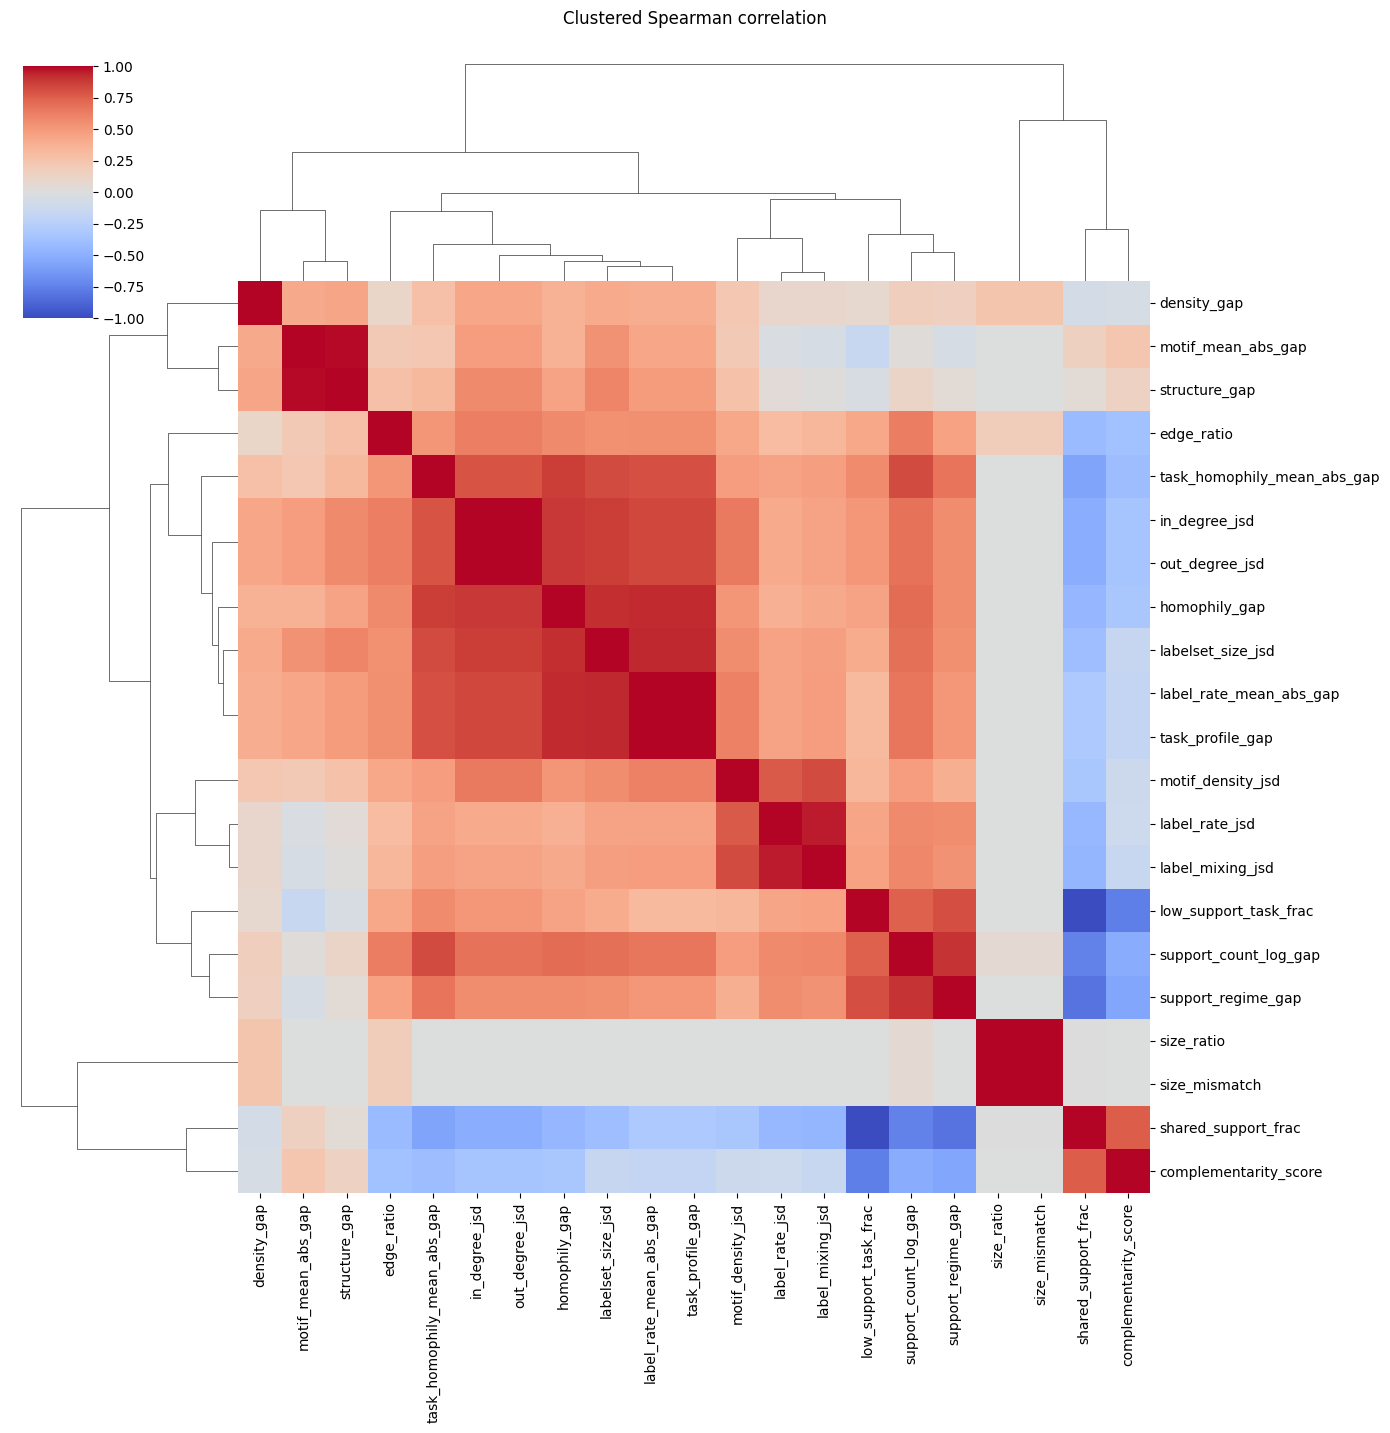

In [25]:
sns.clustermap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    figsize=(14, 14),
    annot=False
)
plt.suptitle("Clustered Spearman correlation", y=1.02)
plt.show()

In [26]:
corr = spearman_corr.abs()

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

pairs.head(20)

size_ratio               size_mismatch                  1.000000
label_rate_mean_abs_gap  task_profile_gap               1.000000
shared_support_frac      low_support_task_frac          1.000000
in_degree_jsd            out_degree_jsd                 0.999218
motif_mean_abs_gap       structure_gap                  0.987803
label_rate_jsd           label_mixing_jsd               0.959411
labelset_size_jsd        task_profile_gap               0.935915
label_rate_mean_abs_gap  labelset_size_jsd              0.935915
                         homophily_gap                  0.923471
homophily_gap            task_profile_gap               0.923471
labelset_size_jsd        homophily_gap                  0.916719
support_count_log_gap    support_regime_gap             0.899627
in_degree_jsd            homophily_gap                  0.884745
out_degree_jsd           homophily_gap                  0.884612
homophily_gap            task_homophily_mean_abs_gap    0.873777
in_degree_jsd            

In [27]:
csv_path_selected = ROOT / "andrea/heterogeneity/selected_pairs.csv"


df_selected = pd.read_csv(csv_path_selected)
print(df_selected.shape)
df_selected.head()

(21, 32)


,family,rank_within_family,selection_score,subset_id,subset_size,subset_clients,graph_id_i,graph_id_j,dataset_i,dataset_j,...,label_top_gap_value,motif_top_gap_task,motif_top_gap_value,task_homophily_top_gap_task,task_homophily_top_gap_value,label_rates_i_json,label_rates_j_json,label_counts_i_json,label_counts_j_json,label_gap_json
0,complementary,1,7.011444,p_447_540,2,447|540,447,540,data_2000_10_1.5_chordal,data_2000_6_2.0_watts,...,0.90700,cycle2,0.8990,cycle2,0.908280,"[0.907, 0.9305, 0.9235, 0.8825, 0.851]","[0.0, 0.916, 0.927, 0.911, 0.8905]","[1814.0, 1861.0, 1847.0, 1765.0, 1702.0]","[0.0, 1832.0, 1854.0, 1822.0, 1781.0]","[{""task"": ""cycle2"", ""value_i"": 0.907, ""value_j..."
1,complementary,2,7.011437,p_204_447,2,204|447,204,447,data_2000_5_4.0_watts,data_2000_10_1.5_chordal,...,0.90700,cycle2,0.8990,cycle2,0.908280,"[0.0, 0.916, 0.9215, 0.9055, 0.879]","[0.907, 0.9305, 0.9235, 0.8825, 0.851]","[0.0, 1832.0, 1843.0, 1811.0, 1758.0]","[1814.0, 1861.0, 1847.0, 1765.0, 1702.0]","[{""task"": ""cycle2"", ""value_i"": 0.0, ""value_j"":..."
2,complementary,3,7.009001,p_447_691,2,447|691,447,691,data_2000_10_1.5_chordal,data_2000_5_1.5_watts,...,0.90700,cycle2,0.8990,cycle2,0.908280,"[0.907, 0.9305, 0.9235, 0.8825, 0.851]","[0.0, 0.922, 0.934, 0.907, 0.904]","[1814.0, 1861.0, 1847.0, 1765.0, 1702.0]","[0.0, 1844.0, 1868.0, 1814.0, 1808.0]","[{""task"": ""cycle2"", ""value_i"": 0.907, ""value_j..."
3,homophily_only,1,2.481424,p_573_806,2,573|806,573,806,data_4000_2_8.5_chordal,data_4000_4_1.0_chordal,...,0.49175,cycle2,0.3060,cycle6,0.350333,"[0.02925, 0.02825, 0.01625, 0.00875, 0.00925]","[0.521, 0.2855, 0.10425, 0.016, 0.0035]","[117.0, 113.0, 65.0, 35.0, 37.0]","[2084.0, 1142.0, 417.0, 64.0, 14.0]","[{""task"": ""cycle2"", ""value_i"": 0.02925, ""value..."
4,homophily_only,2,2.451371,p_83_806,2,83|806,83,806,data_4000_2_7.0_chordal,data_4000_4_1.0_chordal,...,0.49075,cycle2,0.3055,cycle6,0.343885,"[0.03025, 0.02725, 0.023, 0.01025, 0.01425]","[0.521, 0.2855, 0.10425, 0.016, 0.0035]","[121.0, 109.0, 92.0, 41.0, 57.0]","[2084.0, 1142.0, 417.0, 64.0, 14.0]","[{""task"": ""cycle2"", ""value_i"": 0.03025, ""value..."
